# DeepDriveSim: 

**DeepDriveSim (DDS)** is a framework for executing asynchronous **AI-steered ensemble simulations** to enable **adaptive sampling** of complex dynamical systems. AI-steered ensembles allow efficient exploration of configuration space and selective refinement of surrogate models by focusing computational effort where information gain is highest.
A DDS workflow typically begins with an initial ensemble of simulations distributed across the available computational resources. Once sufficient simulation data has been collected to initialize surrogate training, a subset of **simulations is paused** to free GPU/CPU resources for the training task. After training completes, the updated ML surrogate is used to evaluate the state of all active simulations and rank them based on expected utility. Low-utility simulations (those unlikely to yield informative trajectories) are **terminated to free resources** for new simulations drawn from the initial configuration pool.

This closed AI-in-the-loop cycle — simulate → train → select → resample — allows DDS to continuously focus computational effort on the most promising regions of configuration space, improving sampling efficiency and accelerating the convergence of the surrogate model. **This adaptive loop continues iteratively until all simulation tasks in the design space have been executed to completion.**



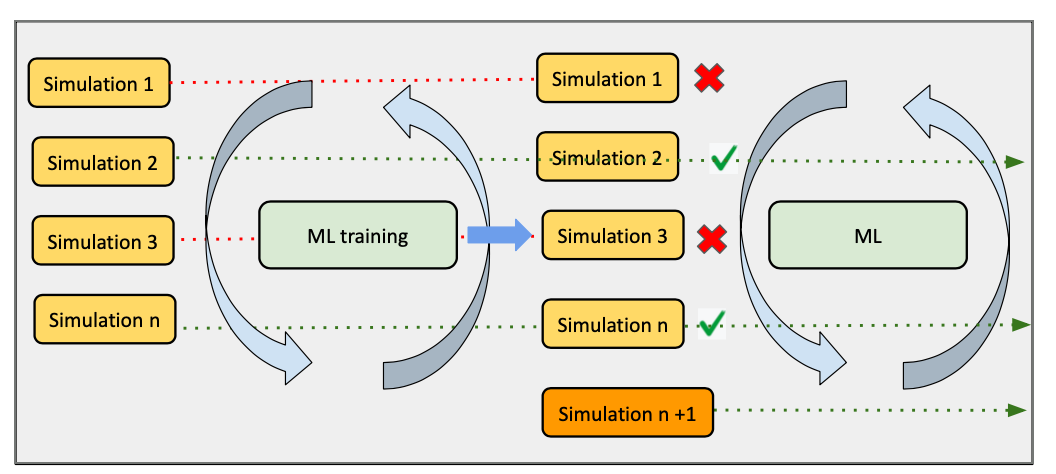


To introduce DDS concepts, we use a **DummyWorkflow** — a simplified workflow that mirrors the DDS control loop, and allows us to demonstrate the end-to-end DDS execution flow without dependence on a real simulation code.

In [1]:
import asyncio
from radical.asyncflow import WorkflowEngine
from radical.asyncflow import ConcurrentExecutionBackend
from concurrent.futures import ProcessPoolExecutor
from ddmd import DummyWorkflow

In [2]:
SIM_CORES = 3
TRAIN_CORE = 1
SRC_DIR = '/ocean/projects/dmr170002p/goliyad/DeepDriveMD/examples/dummy_pipeline'

In [3]:
!ls /ocean/projects/dmr170002p/goliyad/DeepDriveMD/examples/dummy_pipeline/*py

/ocean/projects/dmr170002p/goliyad/DeepDriveMD/examples/dummy_pipeline/__init__.py
/ocean/projects/dmr170002p/goliyad/DeepDriveMD/examples/dummy_pipeline/active_learn.py
/ocean/projects/dmr170002p/goliyad/DeepDriveMD/examples/dummy_pipeline/check_accuracy.py
/ocean/projects/dmr170002p/goliyad/DeepDriveMD/examples/dummy_pipeline/predict.py
/ocean/projects/dmr170002p/goliyad/DeepDriveMD/examples/dummy_pipeline/run_dummy_pipeline.py
/ocean/projects/dmr170002p/goliyad/DeepDriveMD/examples/dummy_pipeline/simulation.py
/ocean/projects/dmr170002p/goliyad/DeepDriveMD/examples/dummy_pipeline/train.py


In [4]:
async def run_ddmd():

    engine = await ConcurrentExecutionBackend(ProcessPoolExecutor())
    #engine = await RadicalExecutionBackend(RESOURCES, raptor_config)

    # Create the async workflow engine
    asyncflow = await WorkflowEngine.create(engine)
    
    # Initialize the workflow
    workflow = DummyWorkflow(asyncflow=asyncflow, 
                             training_cores=TRAIN_CORE, 
                             max_sim_batch=SIM_CORES,
                             src_dir=SRC_DIR)
    
    try:
        # Run the workflow
        await workflow.teach()
    except Exception as e:
        print(f"An error occurred during teaching: {e}")
    finally:
        # Ensure cleanup regardless of errors
        await workflow.close()

In [5]:
await run_ddmd()

15:07:43.885 [INFO] [MANAGER] DDSim Manager initialized on device: cpu
==================== DDSim MANAGER STARTING ====================
15:07:43.945 [INFO] [SIMULATION] Task started: Sim config_11
15:07:43.947 [INFO] [SIMULATION] Task started: Sim config_13
15:07:43.947 [INFO] [SIMULATION] Task started: Sim config_19
15:07:43.948 [INFO] [SIMULATION] Task started: Sim config_22
15:07:43.949 [INFO] [MANAGER] Submitted 4 new simulation(s)
15:08:03.951 [INFO] [MANAGER] Training can start now.
15:08:03.953 [WARNING] [SIMULATION] Task killed: Cancelling Sim config_11 to free training resources
15:08:03.953 [INFO] [MANAGER] Cancelled 1 simulations; Training will now start.
15:08:03.954 [INFO] [MANAGER] Re-added Sim config_11 back the queue
15:08:03.955 [INFO] [MANAGER] 3 simulation(s) running...
15:08:03.955 [INFO] [TRAINING] Iteration 1 / Epoch 1
15:08:04.148 [INFO] [TRAINING] Task started: Model Training
stop criterion metric: model_accuracy is met with value of: 0.7409820062070385 . Breaki



Here is an example of a custom pipeline **DummyWorkflow** we used to illustrate the DDS flow.




In [6]:
import asyncio
import os
import sys
import random
import shutil
import yaml
import numpy as np
from pathlib import Path
from ddmd.ddmd_manager import DDMD_manager
from rose.metrics import MODEL_ACCURACY


class DummyWorkflow(DDMD_manager):
    """Dummy workflow for managing DDMD simulations, training, and predictions."""

    def __init__(self, **kwargs):
        # Default home directory

        self.selection = None
        home_dir = Path(kwargs.get('home_dir', Path.home() / 'DDSim'))
        self._clean_dir(home_dir)  # ❗Careful: deletes everything in home_dir!

        # Create workflow directories
        self.sim_output_dir = self._ensure_dir(kwargs.get('sim_output_dir', home_dir / 'sim_output'))
        self.sim_inputs_dir = self._ensure_dir(kwargs.get('sim_inputs_dir', home_dir / 'sim_input'))
        self.train_dir      = self._ensure_dir(kwargs.get('train_dir', home_dir / 'train'))
        self.train_al_dir   = self._ensure_dir(kwargs.get('train_al_dir', home_dir / 'train_al'))
        self.val_dir        = self._ensure_dir(kwargs.get('val_dir', home_dir / 'val'))

        # Simulation/training config
        self.max_sim_batch            = kwargs.get('max_sim_batch', 4)
        self.training_cores           = kwargs.get('training_cores', 1)
        self.sim_batch_size           = self.max_sim_batch + self.training_cores
        self.training_threshold       = kwargs.get('training_threshold', 0.5)
        self.prediction_threshold     = kwargs.get('prediction_threshold', 0.5)
        self.start_training_threshold = kwargs.get('start_training_threshold', 10)
        self.training_epochs          = kwargs.get('training_epochs', 1)
        self.force_start_training     = bool(kwargs.get("force_start_training", False))
        self.run_prediction_as_exe    = bool(kwargs.get("run_prediction_as_exe", True))

        self.clean_unregistered_sims    = bool(kwargs.get("clean_unregistered_sims", True))

        self.iteration = 0
        self.retrain_model = self.training_epochs > 0
        self.sim_predictions = {}

        # Paths for executables and model
        self.src_dir = kwargs.get('src_dir', os.getcwd())
        self.code_path = kwargs.get('code_path', f'{sys.executable} {self.src_dir}')
        self.model_filename = home_dir / 'model.pkl'
        self.prediction_file = home_dir / 'predictions.yml'  # fixed typo ("predicions")

        # Initialize parent class (sets up asyncflow, logger, queues, etc.)
        asyncflow = kwargs.get('asyncflow')
        super().__init__(asyncflow)

        # Register learner tasks
        self._register_learner_tasks()
        num_files = kwargs.get('num_files', 25)
        # Generate dummy input files
        self._generate_sim_inputs(self.sim_inputs_dir, num_files=num_files)

    # --------------------------------------------------------------------------
    @staticmethod
    def _ensure_dir(path):
        """Create directory if it does not exist."""
        path = Path(path)
        path.mkdir(parents=True, exist_ok=True)
        return path

    # --------------------------------------------------------------------------
    @staticmethod
    def _clean_dir(dir_name):
        """Delete an existing directory (used for a clean workflow run)."""
        dir_path = Path(dir_name)
        if dir_path.exists() and dir_path.is_dir():
            shutil.rmtree(dir_path)

    # --------------------------------------------------------------------------
    @staticmethod
    def _generate_sim_inputs(sim_inputs_dir, num_files: int = 5):
        """
        Generate dummy input `.npz` files for simulations.
        """
        sim_inputs_path = Path(sim_inputs_dir)
        for i in range(num_files):
            file_path = sim_inputs_path / f"config_{i}.npz"
            X = np.random.rand(100, 1)  # Dummy input data
            np.savez(file_path, X=X)
    # Register simulation / training / active learning / prediction tasks with ROSE Learner 
    # --------------------------------------------------------------------------
    def _register_learner_tasks(self):
        """Register learner tasks: simulation, training, active learning, prediction."""

        @self.learner.simulation_task()
        async def simulation(*args, **kwargs):
            sim_tag = kwargs["sim_inputs"]["sim_tag"]
            args = f'--output_dir {self.sim_output_dir} --sim_tag {sim_tag}'
            return f'{self.code_path}/simulation.py {args}'
        self.simulation = simulation

        @self.learner.training_task()
        async def training(*args, **kwargs):
            args = (
                f'--model_filename {self.model_filename} '
                f'--sim_output_dir {self.sim_output_dir} '
                f'--train_dir {self.train_al_dir} --val_dir {self.val_dir}'
            )
            return f'{self.code_path}/train.py {args}'
        self.training = training

        @self.learner.active_learn_task()
        async def active_learn(*args, **kwargs):
            args = (
                f'--model_filename {self.model_filename} '
                f'--train_dir {self.train_dir} '
                f'--train_al_dir {self.train_al_dir}'
            )
            return f'{self.code_path}/active_learn.py {args}'
        self.active_learn = active_learn

        @self.learner.prediction_task(as_executable=True)
        async def exe_prediction(*args, **kwargs):
            args = (
                f'--model_filename {self.model_filename} '
                f'--sim_output_dir {self.sim_output_dir} '
                f'--output_file {self.prediction_file}'
            )
            return f'{self.code_path}/predict.py {args}'
        self.exe_prediction = exe_prediction

        @self.learner.prediction_task(as_executable=False)
        async def prediction(*args, **kwargs):
            """Dummy prediction: assign random score to each sim."""
            sim_inds = list(self.registered_sims.keys())
            return {sim_ind: random.random() for sim_ind in sim_inds}
        self.prediction = prediction

        @self.learner.as_stop_criterion(metric_name=MODEL_ACCURACY, threshold=self.training_threshold)
        async def check_accuracy(*args, **kwargs):
            args = f'--model_filename {self.model_filename} --val_dir {self.val_dir}'
            return f'{self.code_path}/check_accuracy.py {args}'
        self.check_accuracy = check_accuracy

    # Custom decision logic for simulation termination based on model predictions.
    # --------------------------------------------------------------------------
    def stop_simulation(self, *args, **kwargs) -> bool:
        """Return True if prediction < threshold (cancel simulation)."""
        return kwargs['prediction'] < self.prediction_threshold
        
    # Function to collect all prediction results after the completion of the prediction_task.
    # --------------------------------------------------------------------------
    async def collect_predictions(self) -> dict:
        with open(self.prediction_file, 'r') as f:
            predictions = yaml.safe_load(f)
        return predictions

    # Function to enqueue all simulation input data.
    # --------------------------------------------------------------------------
    async def init_sim_queue(self) -> None:
        """Collect all simulation input files into task queue."""
        filenames = await asyncio.to_thread(lambda: list(self.sim_inputs_dir.iterdir()))
        for filename in filenames:
            if filename.is_file():
                sim_name = filename.stem
                sim_tag = f'{sim_name}'
                await self.sim_task_queue.put({'sim_tag': sim_tag})

    # --------------------------------------------------------------------------
    async def check_train_data(self) -> bool:
        """Check if enough training data is available to start training."""
        total_files = 0
        for dir in self.sim_output_dir.iterdir():
            if dir.is_dir():
                # Run blocking file listing in thread pool
                filenames = await asyncio.to_thread(lambda: list(dir.iterdir()))
                total_files += len(filenames)
        return total_files >= self.start_training_threshold
    
    # --------------------------------------------------------------------------
    async def clean_sim_data(self, sim_ind) -> None:
        """Asynchronously delete all files associated with a simulation index (safe parallel cleanup)."""

        async def _delete_file(file_path):
            try:
                await asyncio.to_thread(os.remove, file_path)
            except FileNotFoundError:
                self.logger.warning(f"File already removed: {file_path}")
            except Exception as e:
                self.logger.error(f"Error deleting {file_path}: {e}")

        # Collect all deletion tasks (parallel file cleanup)
        tasks = []
        for directory in [self.train_al_dir, self.train_dir, self.val_dir]:
            
            for filename in directory.iterdir():
                if sim_ind in filename.name:
                    tasks.append(_delete_file(filename))
        if tasks:
            await asyncio.gather(*tasks)

        # Remove simulation output directory after files are gone
        sim_dir = Path(self.sim_output_dir, sim_ind)
        try:
            if sim_dir.exists():
                await asyncio.to_thread(shutil.rmtree, sim_dir)
                if self.debug:
                    self.logger.warning(f"Simulation directory has been removed: {sim_dir}")
            else:
                self.logger.warning(f"Simulation directory already removed: {sim_dir}")
        except Exception as e:
            self.logger.error(f"Error deleting directory {sim_dir}: {e}")
        if self.debug:
            self.logger.info(f"Removed all files related to simulation {sim_ind}")

    # --------------------------------------------------------------------------
    async def train_model(self):
        """Train until accuracy threshold is met or epochs are exhausted."""
        self.iteration += 1
        for epoch in range(self.training_epochs):
            self.logger.info(f'Iteration {self.iteration} / Epoch {epoch + 1}', component="training")

            train_task = await self.training()
            self.logger.task_started('Model Training', component="training")

            should_stop, metric_val = await self.check_accuracy(train_task)
            self.logger.task_completed('Model Training', component="training")
            self.logger.task_started('Check Accuracy', component="training")

            if should_stop:
                self.logger.info(f'Accuracy ({metric_val}) reached threshold → stopping training')
                self.retrain_model = False
                self.sim_batch_size += self.training_cores
                break
            self.logger.task_completed('Check Accuracy', component="training")

            self.logger.task_started('Active Learning', component="training")
            al = await self.active_learn()
            self.logger.task_completed('Active Learning', component="training")
